In [7]:
import numpy as np
import math
from scipy.linalg import block_diag
from simulation.camera_model import get_K, get_camera_pose
from simulation.scene_generator import PointsGenerator
from simulation.projection import  project_points,filter_visible
import matplotlib.pyplot as plt

# Verify 8 points algo

In [8]:
import numpy as np
from normalization import normalize

def linear_eq(points1, points2):
    length = min(points1.shape[0], points2.shape[0])
    A = np.zeros((length, 9))
    for i in range(length):
        A[i, 0] = points2[i, 0]*points1[i, 0]
        A[i, 1] = points2[i, 0]*points1[i, 1]
        A[i, 2] = points2[i, 0]
        A[i, 3] = points2[i, 1]*points1[i, 0]
        A[i, 4] = points2[i, 1]*points1[i, 1]
        A[i, 5] = points2[i, 1]
        A[i, 6] = points1[i, 0]
        A[i, 7] = points1[i, 1]
        A[i, 8] = 1
    return A

def eight_point1(points1, points2):

    length = min(points1.shape[0], points2.shape[0])
    #1: Normalization
    T1 = normalize(points1)
    T2 = normalize(points2)
    norm1 = (T1 @ points1.T).T
    norm2 = (T2 @ points2.T).T

    #2: Find the fundamental matrix of the normalized points
    A_hat = linear_eq(norm1, norm2)
    U, S, Vh = np.linalg.svd(A_hat)
    F_hat = Vh[-1, :].reshape(3, 3)

    #3: Replace F_hat but Fprime_hat such that det Fprime_hat = 0
    U1, S1, Vh1 = np.linalg.svd(F_hat)
    S1[2] = 0
    Fprime_hat = U1@np.diag(S1)@Vh1
    
    #4: Denormalize
    F = T2.T@Fprime_hat@T1

    return F

def get_R_t_from_F1(F, K):
    """
    Function to retrieve the rotational matrix and translational matrix 
    given the fundamental matrix, assuming P = [I|0] and P' = [R|t]
    Input:
        - F: Fundamental matrix (3x3, np.array)
        - K: Intrinsic matrix (3x3, np.array)
    Ouput:
        - t:  Translational matrix
        - R1: Rotational matrix (option 1)
        - R2: Rotational matrix (option 2)
    """

    E = K.T@F@K # Essential matrix
    
    W = np.array([
        [0, -1, 0],
        [1, 0, 0],
        [0, 0, 1]
    ])
    Z = np.array([
        [0, 1, 0],
        [-1, 0, 0],
        [0, 0, 0]
    ])
    U, S, Vh = np.linalg.svd(E)
    print(f"Sigma = {S}")
    t = U[:, 2].reshape(-1, 1)
    R1 = U@W@Vh
    R2 = U@W.T@Vh
    if np.linalg.det(R1) < 0: R1 = -R1
    if np.linalg.det(R2) < 0: R2 = -R2
    return t, R1, R2

def P_estimation(t, R1, R2, K, s):
    P_est1 = K@np.hstack((R1, s*t))
    P_est2 = K@np.hstack((R1, -s*t))
    P_est3 = K@np.hstack((R2, s*t))
    P_est4 = K@np.hstack((R2, -s*t))
    return np.stack([P_est1, P_est2, P_est3, P_est4])

def rotation_matrix_to_euler(R):
    """
    Extracts (Roll, Pitch, Yaw) in radians from a 3x3 rotation matrix.
    Assumes ZYX rotation order.
    """
    # 1. Check if we are in Gimbal Lock (Pitch is exactly +/- 90 degrees)
    # We do this by checking if the length of the first two elements of the first column is 0
    sy = math.sqrt(R[0, 0] * R[0, 0] +  R[1, 0] * R[1, 0])
    singular = sy < 1e-6

    if not singular:
        # Normal extraction
        roll  = math.atan2(R[2, 1], R[2, 2])
        pitch = math.atan2(-R[2, 0], sy)
        yaw   = math.atan2(R[1, 0], R[0, 0])
    else:
        # Gimbal lock extraction (Pitch is +/- 90)
        # In this case, Roll and Yaw become mathematically combined, 
        # so we force Yaw to 0 and dump all the rotation into Roll.
        roll  = math.atan2(-R[1, 2], R[1, 1])
        pitch = math.atan2(-R[2, 0], sy)
        yaw   = 0

    # Returns angles in Radians (X, Y, Z)
    return np.array([roll, pitch, yaw])

def reprojection_error(P, points_2d, points_3d):
    """
    Calcule l'erreur de reprojection par point ||x_i - pi(P, X_i)||_2.

    La reprojection de X_i par P :
      [u, v, w]^T = P @ [X, Y, Z, 1]^T
      u_est = u/w,  v_est = v/w

    Paramètres
    P          : (3, 4) ndarray
    points_2d  : (2, N) ndarray — obs pixel (truth)
    points_3d  : (3, N) ndarray — points 3D monde

    Retourne
    errors  : (N,) ndarray — erreur par point en pixels
    rmse    : float
    max_err : float
    """
    N = points_3d.shape[1]
    X_h = np.vstack([points_3d, np.ones((1, N))])
    proj = P @ X_h
    u_est = proj[0] / proj[2]
    v_est = proj[1] / proj[2]
    errors = np.sqrt((u_est - points_2d[0]) ** 2 + (v_est - points_2d[1]) ** 2)
    return errors, np.sqrt(np.mean(errors ** 2)), errors.max()

def plot_points_only(px_true, pts3d, P_est, title="True vs. Reprojected Points"):
    """
    px_true: (2, N) True pixel coordinates (Ground Truth)
    pts3d:   (3, N) True 3D world points
    P_est:   (3, 4) The estimated projection matrix K[R|t]
    """
    
    # 1. Reproject 3D points using the estimated P matrix
    # Convert pts3d to homogeneous (4, N)
    pts3d_h = np.vstack((pts3d, np.ones((1, pts3d.shape[1]))))
    px_reproj_h = P_est @ pts3d_h
    
    # Normalize by the last row (Z) to get final 2D pixel coordinates (2, N)
    px_reproj = px_reproj_h[:2, :] / px_reproj_h[2, :]

    # 2. Plotting
    plt.figure(figsize=(10, 8))
    
    # Plot Ground Truth points (Blue Circles)
    plt.scatter(px_true[0, :], px_true[1, :], c='blue', marker='o', s=40,
                label='Ground Truth (True P)', alpha=0.6)
    
    # Plot Reprojected points (Red Crosses)
    plt.scatter(px_reproj[0, :], px_reproj[1, :], c='red', marker='x', s=60,
                label='Reprojected (Estimated P)', alpha=0.9)

    plt.title(title)
    plt.xlabel("Pixel Coordinate X")
    plt.ylabel("Pixel Coordinate Y")
    plt.legend()
    
    # Invert Y axis to match image coordinate systems (0,0 at top-left)
    plt.gca().invert_yaxis()
    
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# Fundametal matrix method

Points visibles dans les deux caméras : 40 / 80
x'^TFx = -1.1102230246251565e-16
Sigma = [1.80422701e+00 1.52424298e+00 3.92316010e-17]
Pose 0 RMSE: 1.14e+02 px
Pose 1 RMSE: 1.14e+02 px
Pose 2 RMSE: 1.17e+03 px
Pose 3 RMSE: 1.17e+03 px


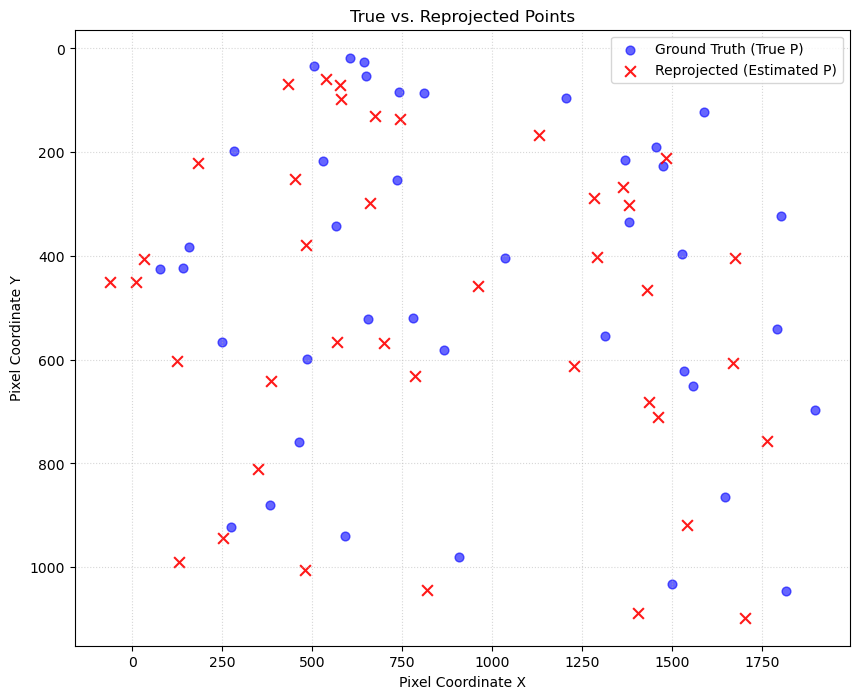

In [9]:
# 1 Génération de la scène 
bounds = np.array([-5, 5, -5, 5, 3, 8])
pts3d = PointsGenerator(nbPoints=80, seed=42, bounds=bounds)  

# 2 Définition des caméras 
K = get_K()
R1, t1 = np.eye(3), np.zeros(3)
R2, t2 = get_camera_pose(rz=10)
norm_t2 = np.linalg.norm(t2)
# 3 Projection 
px1, d1 = project_points(pts3d, K, R1, t1)
px2, d2 = project_points(pts3d, K, R2, t2)

# 4 Filtrage 
vis = filter_visible(px1, d1) & filter_visible(px2, d2)
pts3d_vis = pts3d[:, vis]
print(f"Points visibles dans les deux caméras : {vis.sum()} / {pts3d.shape[1]}")
K_inv = np.linalg.inv(K)
px1_vis = px1[:, vis]
px2_vis = px2[:, vis]

points1 = np.vstack((px1_vis, np.ones((1, px1_vis.shape[1]))))
points2 = np.vstack((px2_vis, np.ones((1, px2_vis.shape[1]))))
points1[2,:] = np.ones((1, px1_vis.shape[1]))
points2[2,:] = np.ones((1, px1_vis.shape[1]))
F = eight_point1(points1.T, points2.T)
print(f"x'^TFx = {points2[:,0].T@F@points1[:,0]}")
t_1, R_1, R_2 = get_R_t_from_F1(F, K)

P_est = P_estimation(t_1, R_1, R_2, K, norm_t2)
rmse = np.zeros((4, 1))
for i in range(4):
    _, rmse[i], _= reprojection_error(P_est[i, :, :], px2_vis, pts3d_vis)
    print(f"Pose {i} RMSE: {rmse[i, 0]:.2e} px")

min_idx = np.argmin(rmse)
plot_points_only(px2_vis, pts3d_vis, P_est[min_idx,:,:], title="True vs. Reprojected Points")


# Essential matrix method

In [10]:
def eight_point1_E(points1, points2, K1, K2):

    length = min(points1.shape[0], points2.shape[0])
    #1: Normalization
    K1_inv = np.linalg.inv(K1)
    K2_inv = np.linalg.inv(K2)
    points1 = K1_inv@points1.T
    points2 = K2_inv@points2.T
    T1 = normalize(points1)
    T2 = normalize(points2)
    norm1 = (T1 @ points1).T
    norm2 = (T2 @ points2).T

    #2: Find the fundamental matrix of the normalized points
    A_hat = linear_eq(norm1, norm2)
    U, Sigma, V = np.linalg.svd(A_hat)
    F_hat = V[8, :].reshape(3, 3)

    #3: Replace F_hat but Fprime_hat such that det Fprime_hat = 0
    U1, Sigma1, V1 = np.linalg.svd(F_hat)
    Sigma1[2] = 0
    Fprime_hat = U1@np.diag(Sigma1)@V1
    
    #4: Denormalize
    F = T2.T@Fprime_hat@T1

    return F

def get_R_t_from_E(E):
    """
    Function to retrieve the rotational matrix and translational matrix 
    given the fundamental matrix, assuming P = [I|0] and P' = [R|t]
    Input:
        - F: Fundamental matrix (3x3, np.array)
        - K: Intrinsic matrix (3x3, np.array)
    Ouput:
        - t:  Translational matrix
        - R1: Rotational matrix (option 1)
        - R2: Rotational matrix (option 2)
    """
    W = np.array([
        [0, -1, 0],
        [1, 0, 0],
        [0, 0, 1]
    ])
    Z = np.array([
        [0, 1, 0],
        [-1, 0, 0],
        [0, 0, 0]
    ])
    U, Sigma, V = np.linalg.svd(E)
    print(f"Sigma = {Sigma}")
    #t = U[:, 2]
    t_2 = U@Z@U.T
    t = np.array([t_2[2,1], t_2[0,2], t_2[1,0]]).reshape(-1, 1)
    R1 = U@W@V
    R2 = U@W.T@V
    if np.linalg.det(R1) < 0: R1 = -R1
    if np.linalg.det(R2) < 0: R2 = -R2
    return t, R1, R2

def P_estimation(t, R1, R2, K, s):
    P_est1 = K@np.hstack((R1, s*t))
    P_est2 = K@np.hstack((R1, -s*t))
    P_est3 = K@np.hstack((R2, s*t))
    P_est4 = K@np.hstack((R2, -s*t))
    return np.stack([P_est1, P_est2, P_est3, P_est4])

def reprojection_error(P, points_2d, points_3d):
    """
    Calcule l'erreur de reprojection par point ||x_i - pi(P, X_i)||_2.

    La reprojection de X_i par P :
      [u, v, w]^T = P @ [X, Y, Z, 1]^T
      u_est = u/w,  v_est = v/w

    Paramètres
    P          : (3, 4) ndarray
    points_2d  : (2, N) ndarray — obs pixel (truth)
    points_3d  : (3, N) ndarray — points 3D monde

    Retourne
    errors  : (N,) ndarray — erreur par point en pixels
    rmse    : float
    max_err : float
    """
    N = points_3d.shape[1]
    X_h = np.vstack([points_3d, np.ones((1, N))])
    proj = P @ X_h
    u_est = proj[0] / proj[2]
    v_est = proj[1] / proj[2]
    errors = np.sqrt((u_est - points_2d[0]) ** 2 + (v_est - points_2d[1]) ** 2)
    return errors, np.sqrt(np.mean(errors ** 2)), errors.max()


Points visibles dans les deux caméras : 40 / 80
x'^TEx = -1.942890293094024e-16
Sigma = [2.58191856e+00 2.58191856e+00 1.10174672e-16]
Pose 0 RMSE: 3.06e+04 px
Pose 1 RMSE: 3.06e+04 px
Pose 2 RMSE: 4.15e-13 px
Pose 3 RMSE: 4.15e-13 px


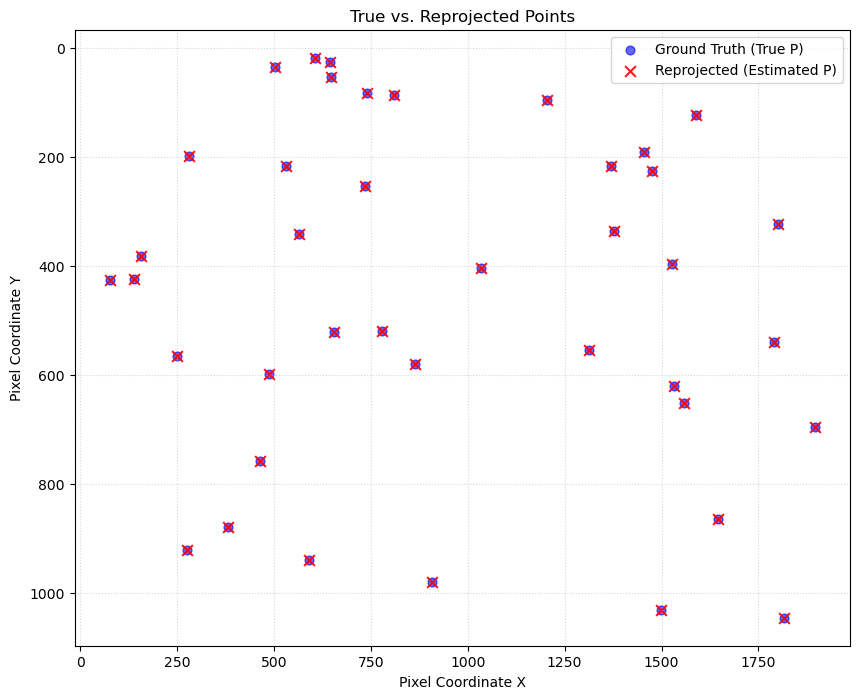

In [11]:
# 1 Génération de la scène 
bounds = np.array([-5, 5, -5, 5, 3, 8])
pts3d = PointsGenerator(nbPoints=80, seed=42, bounds=bounds)  

# 2 Définition des caméras 
K = get_K()
R1, t1 = np.eye(3), np.zeros(3)
R2, t2 = get_camera_pose(rz=10)
norm_t2 = np.linalg.norm(t2)
K_inv = np.linalg.inv(K)
# 3 Projection 
px1, d1 = project_points(pts3d, K, R1, t1)
px2, d2 = project_points(pts3d, K, R2, t2)

# 4 Filtrage 
vis = filter_visible(px1, d1) & filter_visible(px2, d2)
pts3d_vis = pts3d[:, vis]
print(f"Points visibles dans les deux caméras : {vis.sum()} / {pts3d.shape[1]}")
K_inv = np.linalg.inv(K)
px1_vis = px1[:, vis]
px2_vis = px2[:, vis]

points1 = np.vstack((px1_vis, np.ones((1, px1_vis.shape[1]))))
points2 = np.vstack((px2_vis, np.ones((1, px2_vis.shape[1]))))
points1[2,:] = np.ones((1, px1_vis.shape[1]))
points2[2,:] = np.ones((1, px1_vis.shape[1]))
E = eight_point1_E(points1.T, points2.T, K, K)
print(f"x'^TEx = {(K_inv@points2[:,0]).T@E@(K_inv@points1[:,0])}")
t_1, R_1, R_2 = get_R_t_from_E(E)

P_est = P_estimation(t_1, R_1, R_2, K, norm_t2)

rmse = np.zeros((4, 1))
for i in range(4):
    _, rmse[i], _= reprojection_error(P_est[i, :, :], px2_vis, pts3d_vis)
    print(f"Pose {i} RMSE: {rmse[i, 0]:.2e} px")

min_idx = np.argmin(rmse)
plot_points_only(px2_vis, pts3d_vis, P_est[min_idx,:,:], title="True vs. Reprojected Points")